# Classification Track — Ola & Uber Booking Data
Capstone Review 1 (Part A) / Review 2 (Part B) deliverable.
This notebook contains the full 10-algorithm comparison.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# PART 2 — CLASSIFICATION TRACK

## Section A — Dataset & EDA (Ola & Uber Booking Data)

In [2]:
clf_raw = pd.read_csv('bookings_classification_10k.csv')
print("Shape:", clf_raw.shape)
clf_raw.info()


Shape: (10000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Booking_Status  10000 non-null  object
 1   Vehicle_Type    10000 non-null  object
 2   Booking_Value   10000 non-null  int64 
 3   day_of_week     10000 non-null  object
 4   hour            10000 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 390.8+ KB


In [3]:
print(clf_raw.isnull().sum())
print()
print(clf_raw['Booking_Status'].value_counts())


Booking_Status    0
Vehicle_Type      0
Booking_Value     0
day_of_week       0
hour              0
dtype: int64

Booking_Status
Success                 6209
Canceled by Driver      1843
Canceled by Customer     978
Driver Not Found         970
Name: count, dtype: int64


**Observation:** `Booking_Status` has 4 classes (Success, Canceled by Driver, Canceled by Customer, Driver Not Found), with Success dominating (~62%). During preparation I deliberately excluded `V_TAT`, `C_TAT`, `Driver_Ratings`, `Customer_Rating`, `Ride_Distance`, and `Payment_Method` from the feature set — these are populated **only** for Success rows in the raw data (confirmed during EDA), so using them would leak the answer.

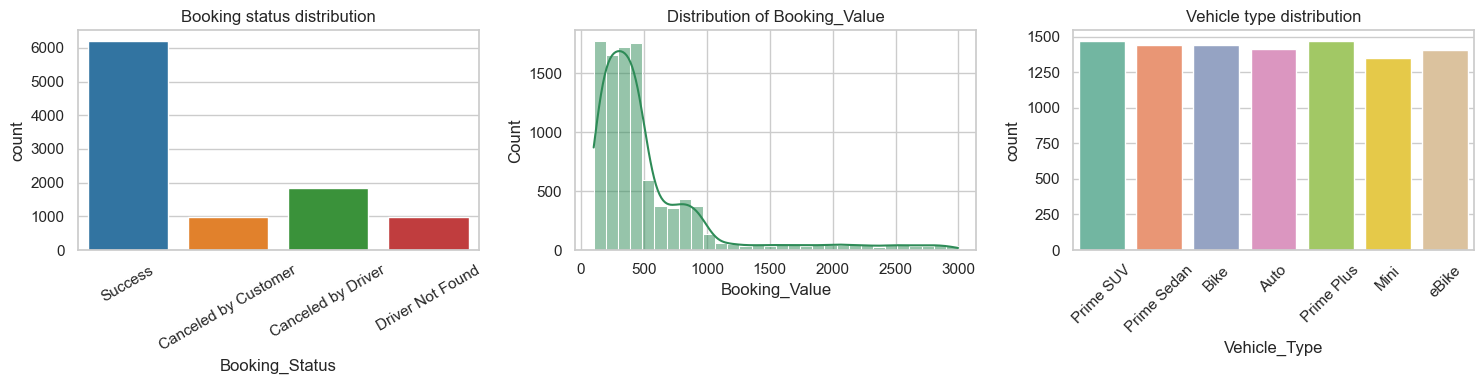

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=clf_raw, x='Booking_Status', hue='Booking_Status', palette='tab10', legend=False, ax=axes[0])
axes[0].set_title('Booking status distribution')
axes[0].tick_params(axis='x', rotation=30)

sns.histplot(clf_raw['Booking_Value'], bins=30, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribution of Booking_Value')

sns.countplot(data=clf_raw, x='Vehicle_Type', hue='Vehicle_Type', palette='Set2', legend=False, ax=axes[2])
axes[2].set_title('Vehicle type distribution')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


**Insight:** class imbalance confirmed (Success ~62%, three cancellation-type classes making up the rest). `Booking_Value` (a pre-ride quoted value present for all outcomes) is roughly normally distributed. Vehicle types are fairly evenly spread across the fleet.